In [7]:
import torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# Set the device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print('device:', device)

device: mps


In [2]:
data = pd.read_csv('ready.csv').drop(columns = 'Unnamed: 0')
data['skew'] = data['OTMP_IV_mean'] - data['ATMC_IV_mean']
data['RI_spread'] = data['RVol_mean'] - data['IVol_mean']
data['CP_spread'] = data['CVol_mean'] - data['PVol_mean']

rank = data.groupby('year_month')['month_exret'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop = True)
data['month_exret_rank'] = rank
data['Top'] = data['month_exret_rank'].apply(lambda x: 1 if x == 4 else 0)
data['Bottom'] = data['month_exret_rank'].apply(lambda x: 1 if x == 0 else 0)

data.drop(columns = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean', 'PVol_mean'], inplace = True)

data_for_model = data[data['year_month']<'2018']

data

,year_month,CUSIP,chmom,dolvol,Idiovol,indmom,maxret,mom1m,mom12m,mvel1,retvol,month_ret,month_exret,skew,RI_spread,CP_spread,month_exret_rank,Top,Bottom
0,1996-02,00154710,0.750294,0.305409,0.057332,0.621315,0.183914,0.553984,0.102541,0.006568,0.092558,0.043916,0.001597,0.032001,-0.041962,-0.069546,3,0,0
1,1996-02,00253A30,0.696998,0.165227,0.200661,0.758034,0.311045,0.828694,0.350606,0.001287,0.278413,-0.102041,-0.138899,-0.028164,-0.347774,-0.024086,0,0,1
2,1996-02,00282410,0.744484,0.717942,0.022986,0.974135,0.145965,0.564528,0.086431,0.262388,0.108329,-0.017646,-0.057942,0.030634,-0.016992,-0.006527,1,0,0
3,1996-02,00507V10,0.726639,0.256219,0.515400,0.619444,0.590862,0.744614,0.159775,0.000400,0.651524,0.092594,0.048120,-0.196498,-0.032070,0.069056,3,0,0
4,1996-02,00724F10,0.552887,0.802481,0.267530,0.619444,0.134598,0.136784,0.081697,0.023960,0.540971,-0.014709,-0.055008,-0.038984,0.023102,0.018708,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426313,2022-12,98980G10,0.289413,0.680486,0.021415,0.189687,0.067773,0.200569,0.045052,0.008343,0.111908,-0.161484,-0.350278,-0.032759,-0.184267,0.004251,0,0,1
426314,2022-12,98980L10,0.265267,0.678716,0.014950,0.189687,0.067542,0.213820,0.041541,0.008372,0.108815,-0.101948,-0.311701,-0.036981,-0.178509,0.003496,1,0,0
426315,2022-12,98981710,0.244653,0.364725,0.010094,0.445670,0.061311,0.260030,0.060627,0.000173,0.091758,-0.064948,-0.266589,-0.022130,-0.155944,-0.000976,2,0,0
426316,2022-12,98983V10,0.270550,0.371030,0.010587,0.189687,0.071569,0.246832,0.045438,0.000388,0.084990,-0.171873,-0.353136,0.017884,-0.175693,-0.002997,0,0,1


# Train With NN3(in > 32 > 16 > 8 > out)
* Label to Predict: Top(1 if in return in month top 20%, else 0), Bottom(1 if in return in month bottom 20%, else 0)
* We Train two models:

1. **topmodel**: using features to predict the probability of the stock being in Top Class
2. **botmodel**: using features to predict the probability of the stock being in Bottom Class

### In Testing Set, We Predict Prababilities of being in Top and Bottom Seperately. 
### Then Calculate the Difference Between two Probabilities.
### Lastly, in each month, we rank the gap and label top 20% as TOP, vice versa.

In [3]:
# 設定隨機種子
np.random.seed(42)
torch.manual_seed(42)

# 將資料分為訓練集和測試集
features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_exret_rank', 'month_ret', 'month_exret', 'Top', 'Bottom'])
labels = data_for_model['Top']
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=42)
    
# 將資料轉換為PyTorch張量並移動到指定的設備
train_features = torch.tensor(train_features.values, dtype=torch.float).to(device)
test_features = torch.tensor(test_features.values, dtype=torch.float).to(device)
train_labels = torch.tensor(train_labels.values, dtype=torch.float).to(device)  # Change to float

class mymodel(nn.Module):
    def __init__(self, input_size, output_size):
        super(mymodel, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4= nn.Linear(8, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)  # Return logits
        x = torch.sigmoid(x)  # Apply sigmoid
        return x

# 建立模型並移動到指定的設備
topmodel = mymodel(train_features.shape[1], 1).to(device) 

# 初始化早停相關變數
patience = 20  # 這個數字表示我們要等待多少個epoch沒有改善就停止訓練
stop_early = 0  # 這個數字用來記錄當前已經等待了多少個epoch
best_loss = float('inf')  # 這個數字用來記錄目前最低的loss
n_epoch = 1000  # 這個數字表示我們要訓練多少個epoch

# 定義損失函數和優化器
weight = torch.tensor(4, dtype=torch.float).to(device)  # Change to a single weight value
criterion = nn.BCEWithLogitsLoss(pos_weight=weight)  # Use pos_weight instead of weight
optimizer = torch.optim.Adam(topmodel.parameters(), lr=0.01)

# 訓練模型
for epoch in range(n_epoch):
    optimizer.zero_grad()
    outputs = topmodel(train_features)
    loss = criterion(outputs, train_labels.unsqueeze(1))
    loss.backward()
    optimizer.step() 

    # 如果當前的loss比最低的loss還要低，則更新最低的loss，並重置等待的epoch數
    if loss.item() < best_loss:
        best_loss = loss.item()
        stop_early = 0
    else:
        stop_early += 1

    # 如果等待的epoch數達到了我們設定的patience，則停止訓練
    if stop_early >= patience:
        print('Early stopping at epoch:', epoch)
        break

    print('Epoch [%d/%d], Loss: %.4f' %(epoch+1, n_epoch, loss.item()))

Epoch [1/1000], Loss: 1.1480
Epoch [2/1000], Loss: 1.1469
Epoch [3/1000], Loss: 1.1457
Epoch [4/1000], Loss: 1.1444
Epoch [5/1000], Loss: 1.1430
Epoch [6/1000], Loss: 1.1414
Epoch [7/1000], Loss: 1.1397
Epoch [8/1000], Loss: 1.1379
Epoch [9/1000], Loss: 1.1359
Epoch [10/1000], Loss: 1.1338
Epoch [11/1000], Loss: 1.1315
Epoch [12/1000], Loss: 1.1292
Epoch [13/1000], Loss: 1.1267
Epoch [14/1000], Loss: 1.1243
Epoch [15/1000], Loss: 1.1218
Epoch [16/1000], Loss: 1.1195
Epoch [17/1000], Loss: 1.1173
Epoch [18/1000], Loss: 1.1154
Epoch [19/1000], Loss: 1.1137
Epoch [20/1000], Loss: 1.1123
Epoch [21/1000], Loss: 1.1113
Epoch [22/1000], Loss: 1.1105
Epoch [23/1000], Loss: 1.1099
Epoch [24/1000], Loss: 1.1095
Epoch [25/1000], Loss: 1.1092
Epoch [26/1000], Loss: 1.1090
Epoch [27/1000], Loss: 1.1088
Epoch [28/1000], Loss: 1.1086
Epoch [29/1000], Loss: 1.1083
Epoch [30/1000], Loss: 1.1079
Epoch [31/1000], Loss: 1.1073
Epoch [32/1000], Loss: 1.1064
Epoch [33/1000], Loss: 1.1053
Epoch [34/1000], Lo

In [4]:
# 設定隨機種子
np.random.seed(42)
torch.manual_seed(42)

# 將資料分為訓練集和測試集
features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_exret_rank', 'month_ret', 'month_exret', 'Top', 'Bottom'])
labels = data_for_model['Bottom']
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=42)
    
# 將資料轉換為PyTorch張量並移動到指定的設備
train_features = torch.tensor(train_features.values, dtype=torch.float).to(device)
test_features = torch.tensor(test_features.values, dtype=torch.float).to(device)
train_labels = torch.tensor(train_labels.values, dtype=torch.float).to(device)  # Change to float

class mymodel(nn.Module):
    def __init__(self, input_size, output_size):
        super(mymodel, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4= nn.Linear(8, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)  # Return logits
        x = torch.sigmoid(x)  # Apply sigmoid
        return x

# 建立 Bot 模型並移動到指定的設備
botmodel = mymodel(train_features.shape[1], 1).to(device) 

# 初始化早停相關變數
patience = 20  # 這個數字表示我們要等待多少個epoch沒有改善就停止訓練
stop_early = 0  # 這個數字用來記錄當前已經等待了多少個epoch
best_loss = float('inf')  # 這個數字用來記錄目前最低的loss
n_epoch = 1000  # 這個數字表示我們要訓練多少個epoch

# 定義損失函數和優化器
weight = torch.tensor(4, dtype=torch.float).to(device)  # Change to a single weight value
criterion = nn.BCEWithLogitsLoss(pos_weight=weight)  # Use pos_weight instead of weight
optimizer = torch.optim.Adam(botmodel.parameters(), lr=0.01)

# 訓練模型
for epoch in range(n_epoch):
    optimizer.zero_grad()
    outputs = botmodel(train_features)
    loss = criterion(outputs, train_labels.unsqueeze(1))
    loss.backward()
    optimizer.step() 

    # 如果當前的loss比最低的loss還要低，則更新最低的loss，並重置等待的epoch數
    if loss.item() < best_loss:
        best_loss = loss.item()
        stop_early = 0
    else:
        stop_early += 1

    # 如果等待的epoch數達到了我們設定的patience，則停止訓練
    if stop_early >= patience:
        print('Early stopping at epoch:', epoch)
        break

    print('Epoch [%d/%d], Loss: %.4f' %(epoch+1, n_epoch, loss.item()))

Epoch [1/1000], Loss: 1.1471
Epoch [2/1000], Loss: 1.1460
Epoch [3/1000], Loss: 1.1449
Epoch [4/1000], Loss: 1.1438
Epoch [5/1000], Loss: 1.1424
Epoch [6/1000], Loss: 1.1409
Epoch [7/1000], Loss: 1.1393
Epoch [8/1000], Loss: 1.1375
Epoch [9/1000], Loss: 1.1356
Epoch [10/1000], Loss: 1.1335
Epoch [11/1000], Loss: 1.1312
Epoch [12/1000], Loss: 1.1288
Epoch [13/1000], Loss: 1.1263
Epoch [14/1000], Loss: 1.1238
Epoch [15/1000], Loss: 1.1213
Epoch [16/1000], Loss: 1.1188
Epoch [17/1000], Loss: 1.1166
Epoch [18/1000], Loss: 1.1145
Epoch [19/1000], Loss: 1.1127
Epoch [20/1000], Loss: 1.1112
Epoch [21/1000], Loss: 1.1100
Epoch [22/1000], Loss: 1.1092
Epoch [23/1000], Loss: 1.1085
Epoch [24/1000], Loss: 1.1081
Epoch [25/1000], Loss: 1.1077
Epoch [26/1000], Loss: 1.1075
Epoch [27/1000], Loss: 1.1073
Epoch [28/1000], Loss: 1.1071
Epoch [29/1000], Loss: 1.1069
Epoch [30/1000], Loss: 1.1066
Epoch [31/1000], Loss: 1.1062
Epoch [32/1000], Loss: 1.1055
Epoch [33/1000], Loss: 1.1045
Epoch [34/1000], Lo

# Model Evaluation on Validation Set

In [5]:
# 測試 Top&Bot 模型
topmodel.eval()
botmodel.eval()
    
with torch.no_grad():
    topoutputs = topmodel(test_features)
    botoutputs = botmodel(test_features)

# 創建一個新的 DataFrame 包含測試集的 'year_month', 'CUSIP', 'month_exret_rank', 'month_ret', 'month_exret', 'Top', 'Bottom' 列
test_df = data_for_model.loc[test_labels.index, ['year_month', 'CUSIP', 'month_exret_rank', 'month_ret', 'month_exret', 'Top', 'Bottom']]

# 將預測概率添加到新的 'Top_prob_pred' 列
test_df['Top_prob_pred'] = topoutputs.cpu().numpy()
test_df['Bot_prob_pred'] = botoutputs.cpu().numpy()

test_df.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
test_df['tmb'] = test_df['Top_prob_pred'] - test_df['Bot_prob_pred']

# 每個月份中預測概率最高的20%的樣本分類為1
test_df['top_preds'] = test_df.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
test_df['bot_preds'] = test_df.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)

# 計算準確率
topaccuracy = accuracy_score(test_df['Top'], test_df['top_preds'])
botaccuracy = accuracy_score(test_df['Bottom'], test_df['bot_preds'])
print('Top Model accuracy:', topaccuracy)
print('Bot Model accuracy:', botaccuracy)

Top Model accuracy: 0.7077047884084164
Bot Model accuracy: 0.7113913391729393


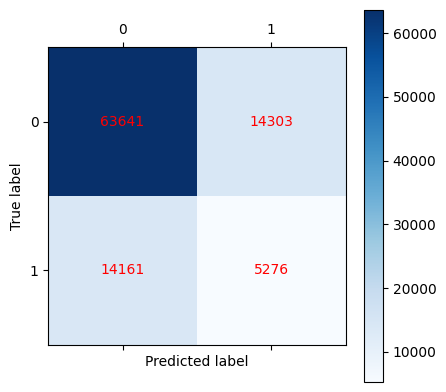

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 計算混淆矩陣
cm = confusion_matrix(test_df['Top'], test_df['top_preds'])

# 繪製混淆矩陣
plt.matshow(cm, cmap='Blues')
plt.colorbar()

# 在每個格子中添加數值
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

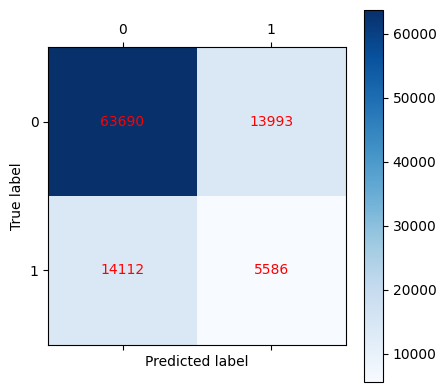

In [7]:
# 計算混淆矩陣
cm = confusion_matrix(test_df['Bottom'], test_df['bot_preds'])

# 繪製混淆矩陣
plt.matshow(cm, cmap='Blues')
plt.colorbar()

# 在每個格子中添加數值
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# Backtest v.s. US Equity ETFs

In [5]:
data_for_backtest = data[data['year_month']>='2018'].copy()

features = data_for_backtest.drop(columns=['year_month', 
                                        'CUSIP', 
                                        'month_exret_rank', 
                                        'month_ret', 
                                        'month_exret', 
                                        'Top', 
                                        'Bottom'])
topmodel.eval()
botmodel.eval()
with torch.no_grad():
    bt_top_prob = topmodel(torch.tensor(features.values, dtype=torch.float).to(device))
    bt_bot_prob = botmodel(torch.tensor(features.values, dtype=torch.float).to(device))

bt_top_prob = bt_top_prob.cpu().numpy()
bt_bot_prob = bt_bot_prob.cpu().numpy()

data_for_backtest.loc[:, 'Top_prob_pred'] = bt_top_prob
data_for_backtest.loc[:, 'Bot_prob_pred'] = bt_bot_prob

data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['Top_prob_pred'] - data_for_backtest['Bot_prob_pred']

# 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)


In [10]:
import pandas as pd

pd.set_option('display.max_columns', None)

data_for_backtest

,year_month,CUSIP,chmom,dolvol,Idiovol,indmom,maxret,mom1m,mom12m,mvel1,retvol,month_ret,month_exret,skew,RI_spread,CP_spread,month_exret_rank,Top,Bottom,Top_prob_pred,Bot_prob_pred,tmb,top_preds,bot_preds
324601,2018-01,00030710,0.436917,0.266899,0.138854,0.380277,0.025752,0.197113,0.133095,0.000180,0.061480,-0.005556,-0.035397,-0.084412,-0.263573,0.201018,1,0,0,4.161401e-01,3.719073e-01,4.423285e-02,1,0
324602,2018-01,00081T10,0.420476,0.379232,0.018956,0.214450,0.012772,0.162523,0.095219,0.001482,0.037276,-0.028690,-0.057499,-0.064705,-0.132388,0.113939,1,0,0,4.927128e-03,1.290798e-02,-7.980848e-03,0,0
324603,2018-01,00095710,0.397300,0.474808,0.012228,0.438618,0.017270,0.134826,0.095686,0.002948,0.075473,0.012896,-0.018054,-0.031673,-0.022689,0.064404,1,0,0,5.418696e-04,6.664658e-03,-6.122789e-03,0,0
324604,2018-01,00105510,0.408022,0.665220,0.001508,0.380277,0.004075,0.206558,0.138855,0.039327,0.008670,0.004785,-0.026126,-0.012639,-0.059402,0.034600,1,0,0,8.140009e-13,5.042931e-10,-5.034790e-10,0,0
324605,2018-01,00130H10,0.408633,0.606509,0.010722,0.000000,0.007943,0.219696,0.099913,0.008004,0.023482,0.079409,0.046353,-0.022735,-0.066953,0.048499,3,0,0,1.539872e-12,2.697655e-04,-2.697655e-04,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426313,2022-12,98980G10,0.289413,0.680486,0.021415,0.189687,0.067773,0.200569,0.045052,0.008343,0.111908,-0.161484,-0.350278,-0.032759,-0.184267,0.004251,0,0,1,1.347703e-02,3.284521e-01,-3.149750e-01,0,1
426314,2022-12,98980L10,0.265267,0.678716,0.014950,0.189687,0.067542,0.213820,0.041541,0.008372,0.108815,-0.101948,-0.311701,-0.036981,-0.178509,0.003496,1,0,0,1.117364e-03,2.628060e-01,-2.616886e-01,0,1
426315,2022-12,98981710,0.244653,0.364725,0.010094,0.445670,0.061311,0.260030,0.060627,0.000173,0.091758,-0.064948,-0.266589,-0.022130,-0.155944,-0.000976,2,0,0,1.009415e-02,2.411136e-01,-2.310195e-01,0,0
426316,2022-12,98983V10,0.270550,0.371030,0.010587,0.189687,0.071569,0.246832,0.045438,0.000388,0.084990,-0.171873,-0.353136,0.017884,-0.175693,-0.002997,0,0,1,1.066877e-03,2.651532e-01,-2.640863e-01,0,1


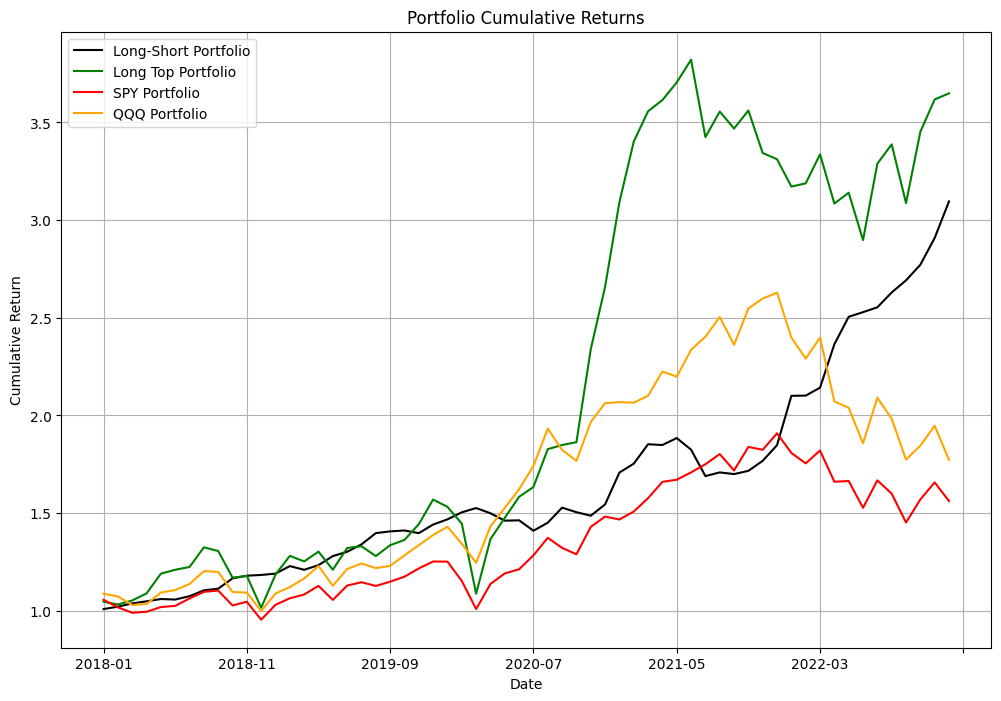

In [8]:
# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
bt = pd.concat([top_ptf_ret, bot_ptf_ret], axis=1)
bt['long_short'] = bt['top_ptf_ret'] - bt['bot_ptf_ret']

# Get Market Return (SPY and QQQ)
mkt = pd.read_csv('SPY_and_QQQ.csv')
mkt = mkt[['Ticker', 'YYYYMM', 'MthRet']]\
    .rename(columns={'YYYYMM': 'year_month'})
    
mkt['year_month'] = mkt['year_month'].astype(str)
mkt['year_month'] = mkt['year_month'].apply(lambda x: x[:4] + '-' + x[4:])
mkt.set_index('year_month', inplace=True)

spy = mkt[mkt['Ticker'] == 'SPY'].copy().rename(columns={'MthRet': 'spy_ret'}).drop(columns=['Ticker'])
qqq = mkt[mkt['Ticker'] == 'QQQ'].copy().rename(columns={'MthRet': 'qqq_ret'}).drop(columns=['Ticker'])

bt['spy_ret'] = spy['spy_ret']
bt['qqq_ret'] = qqq['qqq_ret']

# Calculate Cumulative Long Only and Long/Short Portfolio Return
bt['long_short_cum'] = (bt['long_short'] + 1).cumprod()
bt['long_top_cum'] = (bt['top_ptf_ret'] + 1).cumprod()

# Calculate Cumulative SPY and QQQ Return
bt['spy_cum'] = (bt['spy_ret'] + 1).cumprod()
bt['qqq_cum'] = (bt['qqq_ret'] + 1).cumprod()

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot each cumulative return series with specified colors and labels
bt['long_short_cum'].plot(label='Long-Short Portfolio', color='black')
bt['long_top_cum'].plot(label='Long Top Portfolio', color='green')
bt['spy_cum'].plot(label='SPY Portfolio', color='red')
bt['qqq_cum'].plot(label='QQQ Portfolio', color='orange')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Portfolio Cumulative Returns')

# Add legend
plt.legend()

# Add grid lines
plt.grid(True)

# Show the plot
plt.show()